### Section 1: Initial Setup and Data Loading

# Product Recommendation System - Exploratory Data Analysis

## Project Objective
As a data analyst at getINNOtized, build a Recommendation System capable of providing personalized suggestions based on user behavior and preferences. The system will leverage data from users' past interactions, preferences, and other relevant features to make predictions and generate personalized recommendations for e-commerce platforms.

## Overview
This notebook provides a comprehensive analysis of the e-commerce dataset to build an effective product recommendation system. We'll explore user behavior patterns, product characteristics, and interaction data to develop personalized recommendation algorithms.

## Dataset Structure
- **events.csv**: User interaction events (views, purchases, etc.)
- **category_tree.csv**: Product category hierarchy
- **item_properties_part1.1.csv**: Product properties and metadata (Part 1)
- **item_properties_part2.csv**: Product properties and metadata (Part 2)

In [ ]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For recommendation systems
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# For visualization
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

# For handling large datasets
import gc
import time

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load datasets
print("Loading datasets...")
start_time = time.time()

# Load events data
events_df = pd.read_csv('events.csv')
print(f"Events data loaded: {events_df.shape}")

# Load category tree
category_df = pd.read_csv('category_tree.csv')
print(f"Category tree loaded: {category_df.shape}")

# Load item properties (combining both parts)
item_props_1 = pd.read_csv('item_properties_part1.1.csv')
item_props_2 = pd.read_csv('item_properties_part2.csv')
item_props_df = pd.concat([item_props_1, item_props_2], ignore_index=True)
print(f"Item properties loaded: {item_props_df.shape}")

print(f"\nTotal loading time: {time.time() - start_time:.2f} seconds")

Loading datasets...
Events data loaded: (2756101, 5)
Category tree loaded: (1669, 2)
Item properties loaded: (20275902, 4)

Total loading time: 12.43 seconds


### Section 2: Data Quality Assessment


In [ ]:
# Basic information about each dataset

print("=== EVENTS DATASET ===")
print(f"Shape: {events_df.shape}")
print(f"Columns: {list(events_df.columns)}")
print("\nFirst 5 rows:")
print(events_df.head())

print("\n=== CATEGORY TREE DATASET ===")
print(f"Shape: {category_df.shape}")
print(f"Columns: {list(category_df.columns)}")
print("\nFirst 5 rows:")
print(category_df.head())

print("\n=== ITEM PROPERTIES DATASET ===")
print(f"Shape: {item_props_df.shape}")
print(f"Columns: {list(item_props_df.columns)}")
print("\nFirst 5 rows:")
print(item_props_df.head())

=== EVENTS DATASET ===
Shape: (2756101, 5)
Columns: ['timestamp', 'visitorid', 'event', 'itemid', 'transactionid']

First 5 rows:
       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN

=== CATEGORY TREE DATASET ===
Shape: (1669, 2)
Columns: ['categoryid', 'parentid']

First 5 rows:
   categoryid  parentid
0        1016     213.0
1         809     169.0
2         570       9.0
3        1691     885.0
4         536    1691.0

=== ITEM PROPERTIES DATASET ===
Shape: (20275902, 4)
Columns: ['timestamp', 'itemid', 'property', 'value']

First 5 rows:
       timestamp  itemid    property                            value
0  1435460400000  460429  categoryid                             1338
1  1441508400000  2067

In [5]:
# Data Quality Assessment
print("=== DATA QUALITY ASSESSMENT ===")

# Check for missing values
print("\n1. Missing Values Analysis:")
print("Events Dataset:")
print(events_df.isnull().sum())
print("\nCategory Tree Dataset:")
print(category_df.isnull().sum())
print("\nItem Properties Dataset:")
print(item_props_df.isnull().sum())

# Check for duplicates
print("\n2. Duplicate Analysis:")
print(f"Events duplicates: {events_df.duplicated().sum()}")
print(f"Category duplicates: {category_df.duplicated().sum()}")
print(f"Item properties duplicates: {item_props_df.duplicated().sum()}")

# Data types and basic statistics
print("\n3. Data Types:")
print("Events Dataset:")
print(events_df.dtypes)
print("\nCategory Tree Dataset:")
print(category_df.dtypes)
print("\nItem Properties Dataset:")
print(item_props_df.dtypes)

=== DATA QUALITY ASSESSMENT ===

1. Missing Values Analysis:
Events Dataset:
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

Category Tree Dataset:
categoryid     0
parentid      25
dtype: int64

Item Properties Dataset:
timestamp    0
itemid       0
property     0
value        0
dtype: int64

2. Duplicate Analysis:
Events duplicates: 460
Category duplicates: 0
Item properties duplicates: 0

3. Data Types:
Events Dataset:
timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
dtype: object

Category Tree Dataset:
categoryid      int64
parentid      float64
dtype: object

Item Properties Dataset:
timestamp     int64
itemid        int64
property     object
value        object
dtype: object


### Section 3: Exploratory Data Analysis


=== EVENTS DATASET ANALYSIS ===

1. Event Types Distribution:
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


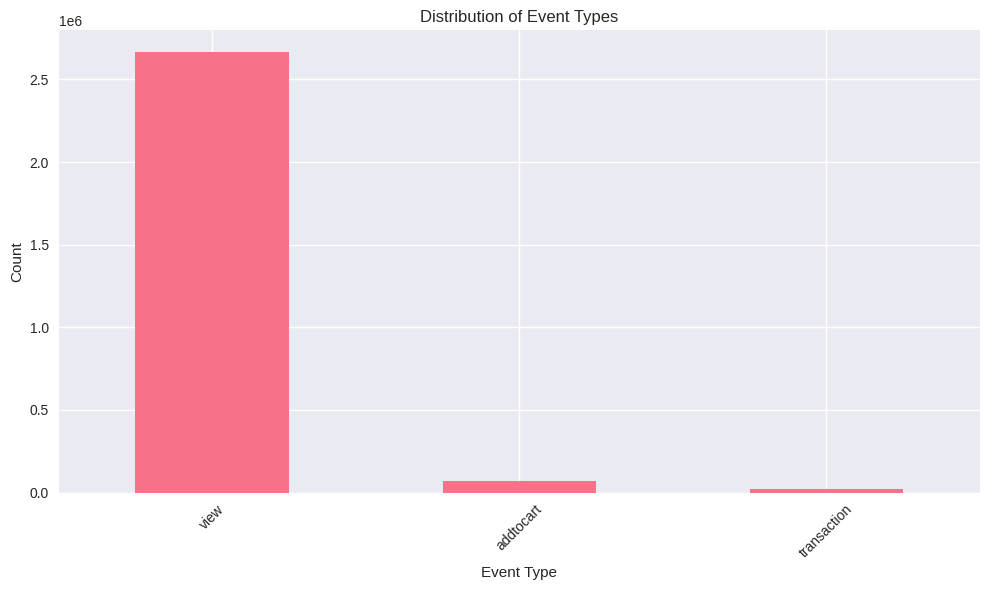

In [6]:
# Convert timestamp to datetime
events_df['timestamp'] = pd.to_datetime(events_df['timestamp'], unit='ms')
item_props_df['timestamp'] = pd.to_datetime(item_props_df['timestamp'], unit='ms')

print("=== EVENTS DATASET ANALYSIS ===")

# Event types distribution
print("\n1. Event Types Distribution:")
event_counts = events_df['event'].value_counts()
print(event_counts)

plt.figure(figsize=(10, 6))
event_counts.plot(kind='bar')
plt.title('Distribution of Event Types')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



2. Time-based Analysis:


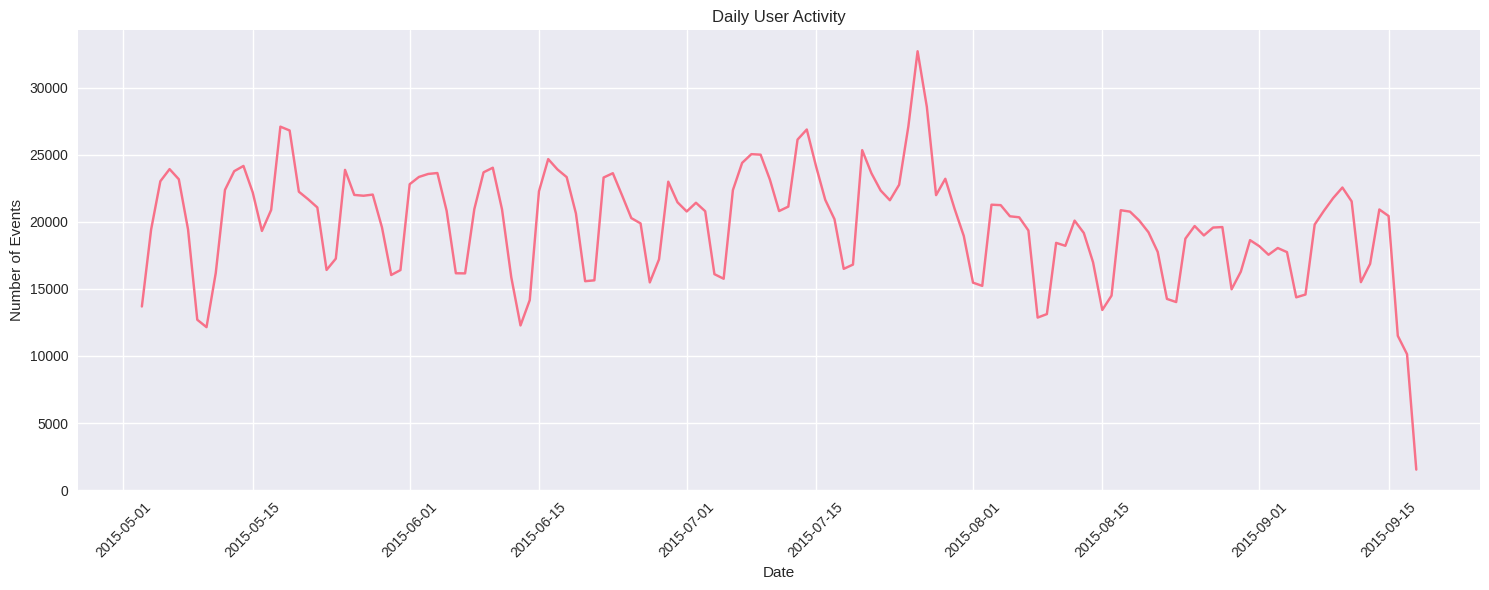

In [7]:

# Time-based analysis
print("\n2. Time-based Analysis:")
events_df['date'] = events_df['timestamp'].dt.date
events_df['hour'] = events_df['timestamp'].dt.hour
events_df['day_of_week'] = events_df['timestamp'].dt.day_name()

# Daily activity
daily_activity = events_df.groupby('date').size()
plt.figure(figsize=(15, 6))
daily_activity.plot(kind='line')
plt.title('Daily User Activity')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



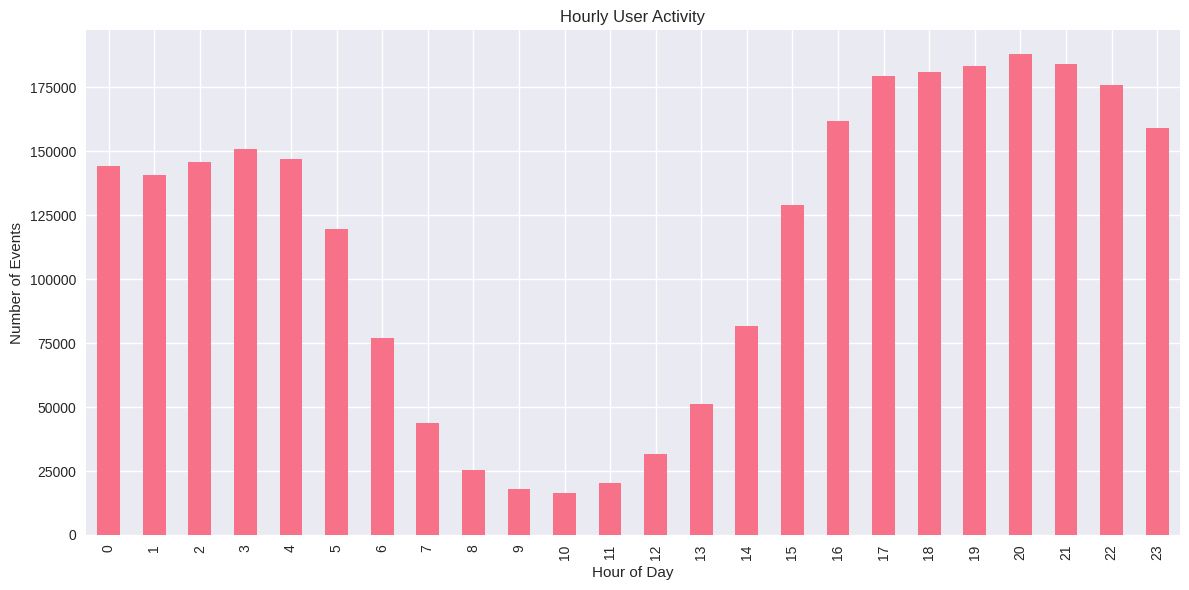

In [8]:
# Hourly activity
hourly_activity = events_df.groupby('hour').size()
plt.figure(figsize=(12, 6))
hourly_activity.plot(kind='bar')
plt.title('Hourly User Activity')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

### Section 4: User Behavior Analysis


In [9]:
print("=== USER BEHAVIOR ANALYSIS ===")

# User activity analysis
user_activity = events_df.groupby('visitorid').agg({
    'event': 'count',
    'itemid': 'nunique',
    'timestamp': ['min', 'max']
}).round(2)

user_activity.columns = ['total_events', 'unique_items', 'first_activity', 'last_activity']
user_activity['activity_duration'] = (user_activity['last_activity'] - user_activity['first_activity']).dt.days

print("\n1. User Activity Summary:")
user_activity.describe()




=== USER BEHAVIOR ANALYSIS ===

1. User Activity Summary:


,total_events,unique_items,first_activity,last_activity,activity_duration
count,1.407580e+06,1.407580e+06,1407580,1407580,1.407580e+06
mean,1.958042e+00,1.524019e+00,2015-07-09 10:16:42.513630208,2015-07-11 19:17:24.858687232,2.318977e+00
min,1.000000e+00,1.000000e+00,2015-05-03 03:00:04.384000,2015-05-03 03:00:11.289000,0.000000e+00
25%,1.000000e+00,1.000000e+00,2015-06-04 21:48:25.778250240,2015-06-08 00:56:58.077500160,0.000000e+00
50%,1.000000e+00,1.000000e+00,2015-07-10 10:54:21.271000064,2015-07-13 01:08:21.987500032,0.000000e+00
75%,2.000000e+00,1.000000e+00,2015-08-11 00:00:35.832500224,2015-08-13 16:42:47.900000,0.000000e+00
max,7.757000e+03,3.814000e+03,2015-09-18 02:59:41.778000,2015-09-18 02:59:47.788000,1.370000e+02
std,1.258049e+01,7.143724e+00,NaN,NaN,1.154139e+01


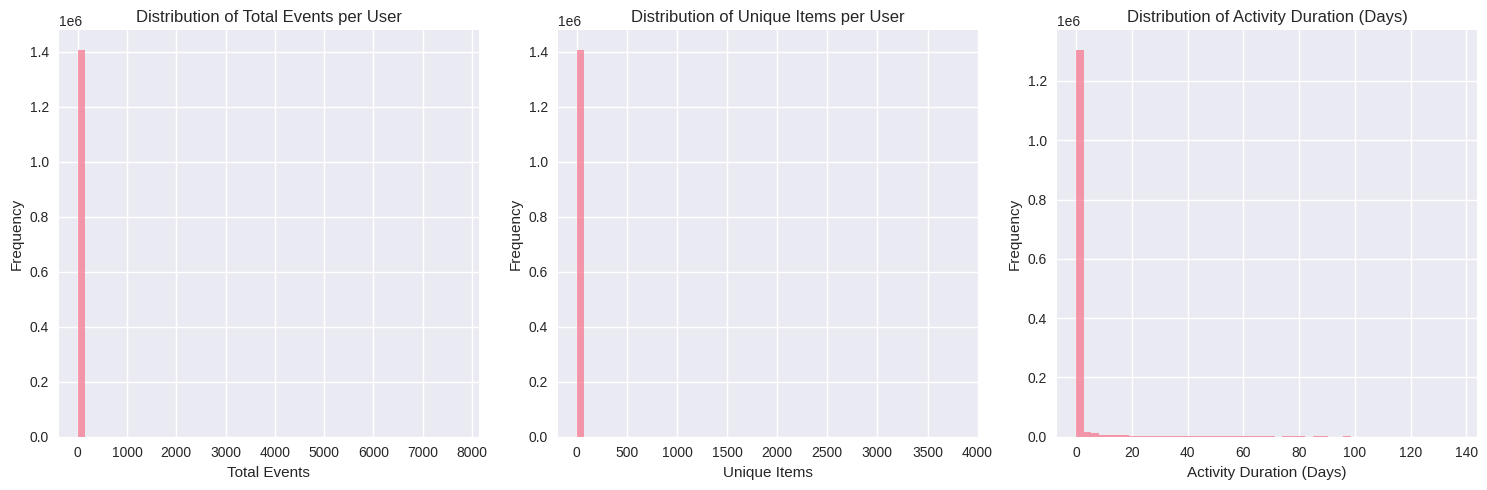

In [10]:

# User engagement distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(user_activity['total_events'], bins=50, alpha=0.7)
plt.title('Distribution of Total Events per User')
plt.xlabel('Total Events')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(user_activity['unique_items'], bins=50, alpha=0.7)
plt.title('Distribution of Unique Items per User')
plt.xlabel('Unique Items')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(user_activity['activity_duration'], bins=50, alpha=0.7)
plt.title('Distribution of Activity Duration (Days)')
plt.xlabel('Activity Duration (Days)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [11]:
# Top users analysis
print("\n2. Top 10 Most Active Users:")
top_users = user_activity.nlargest(10, 'total_events')
top_users.head()


2. Top 10 Most Active Users:


,total_events,unique_items,first_activity,last_activity,activity_duration
visitorid,,,,,
1150086,7757,3814,2015-06-11 14:55:17.389,2015-09-17 02:57:11.237,97
530559,4328,2209,2015-06-15 18:59:25.103,2015-09-17 02:14:14.827,93
152963,3024,1622,2015-07-31 21:14:28.499,2015-09-18 02:48:46.605,48
895999,2474,1641,2015-05-06 15:10:32.815,2015-09-18 02:41:59.083,134
163561,2410,1314,2015-05-03 18:08:45.953,2015-06-04 02:57:16.915,31


### Section 5: Product Analysis


In [12]:
print("=== PRODUCT ANALYSIS ===")

# Item popularity analysis
item_popularity = events_df.groupby('itemid').agg({
    'event': 'count',
    'visitorid': 'nunique'
}).rename(columns={'event': 'total_views', 'visitorid': 'unique_users'})

print("\n1. Item Popularity Summary:")
item_popularity.describe()



=== PRODUCT ANALYSIS ===

1. Item Popularity Summary:


,total_views,unique_users
count,235061.000000,235061.000000
mean,11.725046,9.126052
std,37.032101,27.102543
min,1.000000,1.000000
25%,1.000000,1.000000
50%,3.000000,2.000000
75%,9.000000,7.000000
max,3412.000000,2912.000000


In [13]:
# Top products
print("\n2. Top 10 Most Popular Products:")
top_products = item_popularity.nlargest(10, 'total_views')
top_products.head()




2. Top 10 Most Popular Products:


,total_views,unique_users
itemid,,
187946,3412,2912
461686,2978,1393
5411,2334,2079
370653,1854,1577
219512,1800,1370


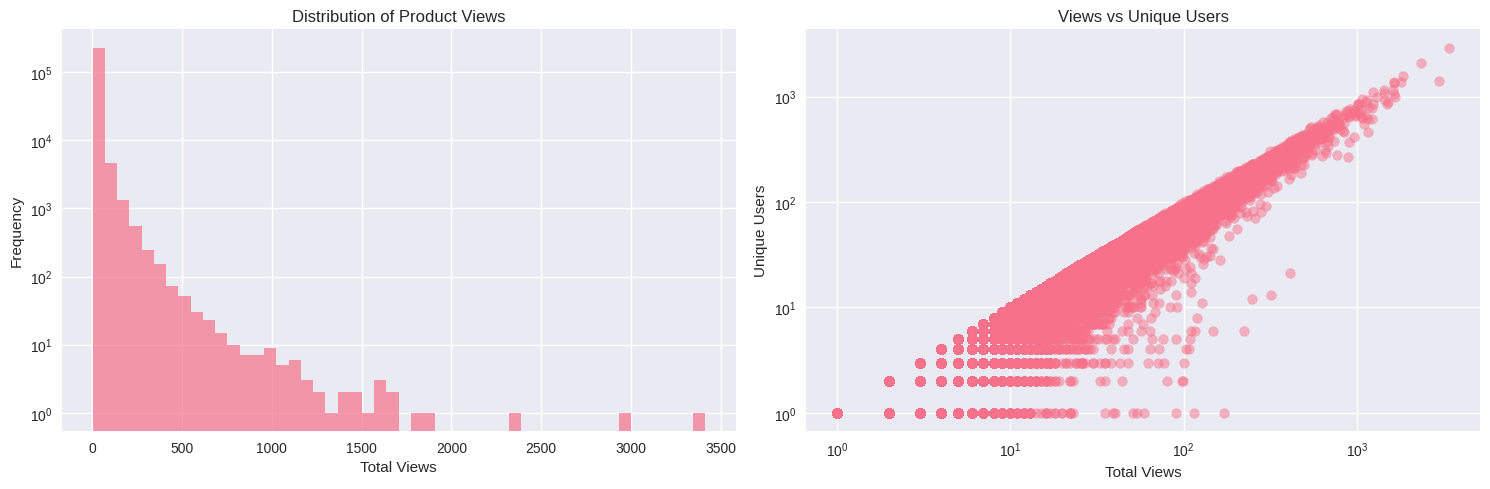

In [14]:
# Product popularity distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(item_popularity['total_views'], bins=50, alpha=0.7)
plt.title('Distribution of Product Views')
plt.xlabel('Total Views')
plt.ylabel('Frequency')
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.scatter(item_popularity['total_views'], item_popularity['unique_users'], alpha=0.5)
plt.title('Views vs Unique Users')
plt.xlabel('Total Views')
plt.ylabel('Unique Users')
plt.yscale('log')
plt.xscale('log')

plt.tight_layout()
plt.show()

### Section 6: Category Analysis


=== CATEGORY ANALYSIS ===

1. Category Tree Analysis:
Total categories: 1669
Categories with parent: 1644
Root categories (no parent): 25


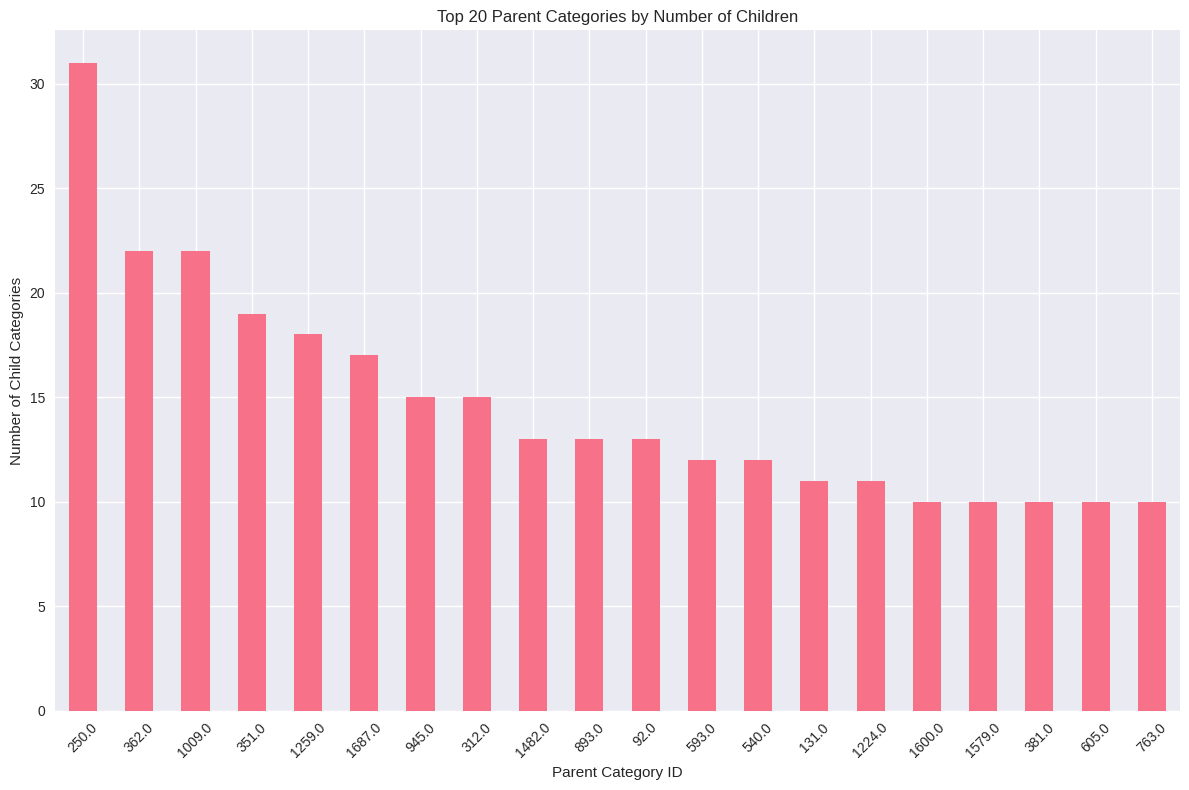

In [15]:
print("=== CATEGORY ANALYSIS ===")

# Analyze category hierarchy
print("\n1. Category Tree Analysis:")
print(f"Total categories: {len(category_df)}")
print(f"Categories with parent: {category_df['parentid'].notna().sum()}")
print(f"Root categories (no parent): {category_df['parentid'].isna().sum()}")

# Category hierarchy visualization
plt.figure(figsize=(12, 8))
category_counts = category_df['parentid'].value_counts().head(20)
category_counts.plot(kind='bar')
plt.title('Top 20 Parent Categories by Number of Children')
plt.xlabel('Parent Category ID')
plt.ylabel('Number of Child Categories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




2. Items with category information: 788214
Events with category info: 2500516


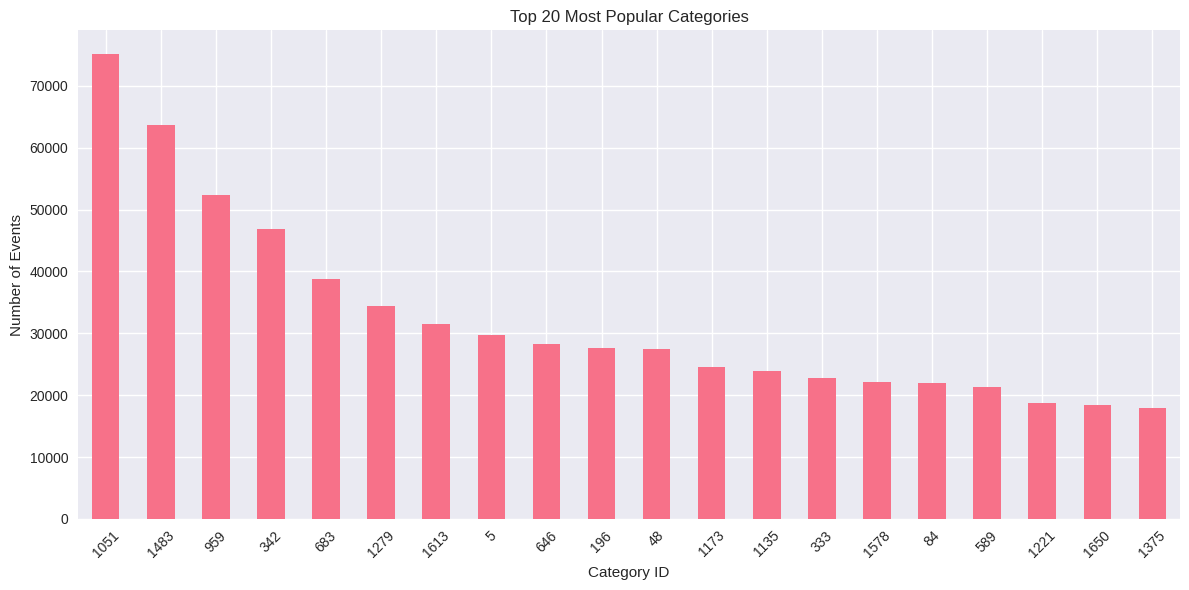

In [16]:
# Merge category information with events
# First, let's see what category information we have in item properties
category_props = item_props_df[item_props_df['property'] == 'categoryid']
print(f"\n2. Items with category information: {len(category_props)}")

# Create item-category mapping
item_category_map = category_props.groupby('itemid')['value'].first().reset_index()
item_category_map.columns = ['itemid', 'categoryid']

# Merge with events
events_with_category = events_df.merge(item_category_map, on='itemid', how='left')
print(f"Events with category info: {events_with_category['categoryid'].notna().sum()}")

# Category popularity
if len(events_with_category) > 0:
    category_popularity = events_with_category.groupby('categoryid').size().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    category_popularity.head(20).plot(kind='bar')
    plt.title('Top 20 Most Popular Categories')
    plt.xlabel('Category ID')
    plt.ylabel('Number of Events')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Section 7: Data Preprocessing


In [17]:
print("=== DATA PREPROCESSING (ENHANCED WITH USER FILTERING) ===")

# 1. Initial Data Analysis
print("\n1. Initial Data Analysis:")

# Analyze user interaction patterns before filtering
user_interaction_counts = events_df.groupby('visitorid').size()
print(f"Total users: {len(user_interaction_counts):,}")
print(f"Average interactions per user: {user_interaction_counts.mean():.2f}")
print(f"Median interactions per user: {user_interaction_counts.median():.2f}")

# Show distribution of user interactions
print("\nUser interaction distribution:")
print(f"Users with 1 interaction: {(user_interaction_counts == 1).sum():,}")
print(f"Users with 2-5 interactions: {((user_interaction_counts >= 2) & (user_interaction_counts <= 5)).sum():,}")
print(f"Users with 6-20 interactions: {((user_interaction_counts >= 6) & (user_interaction_counts <= 20)).sum():,}")
print(f"Users with 21-50 interactions: {((user_interaction_counts >= 21) & (user_interaction_counts <= 50)).sum():,}")
print(f"Users with 51-100 interactions: {((user_interaction_counts >= 51) & (user_interaction_counts <= 100)).sum():,}")
print(f"Users with 100+ interactions: {(user_interaction_counts >= 101).sum():,}")

# 2. Handle Missing Values
print("\n2. Handling Missing Values:")

# Events dataset - remove rows with missing critical data
events_clean = events_df.dropna(subset=['visitorid', 'itemid', 'event'])
print(f"Events after removing missing critical data: {len(events_clean):,}")

# Category tree - fill missing parentid with -1 (root categories)
category_clean = category_df.copy()
category_clean['parentid'] = category_clean['parentid'].fillna(-1)
print(f"Category tree cleaned: {len(category_clean):,}")

# Item properties - remove rows with missing critical data
item_props_clean = item_props_df.dropna(subset=['itemid', 'property'])
print(f"Item properties after cleaning: {len(item_props_clean):,}")

# 3. Data Type Conversions
print("\n3. Data Type Conversions:")
events_clean['visitorid'] = events_clean['visitorid'].astype(int)
events_clean['itemid'] = events_clean['itemid'].astype(int)
category_clean['categoryid'] = category_clean['categoryid'].astype(int)
category_clean['parentid'] = category_clean['parentid'].astype(int)
item_props_clean['itemid'] = item_props_clean['itemid'].astype(int)

print("Data types converted successfully!")

# 4. User Filtering Strategy
print("\n4. User Filtering Strategy:")

# Define filtering threshold (you can adjust this)
MIN_INTERACTIONS = 10  # Users with 20+ interactions

# Analyze different thresholds
filtering_thresholds = [5, 10, 20, 50, 100]

for threshold in filtering_thresholds:
    active_users = user_interaction_counts[user_interaction_counts >= threshold].index
    filtered_events = events_clean[events_clean['visitorid'].isin(active_users)]
    
    print(f"\nThreshold {threshold}+ interactions:")
    print(f"  Active users: {len(active_users):,}")
    print(f"  Filtered events: {len(filtered_events):,}")
    print(f"  Data reduction: {((len(events_clean) - len(filtered_events)) / len(events_clean) * 100):.1f}%")
    print(f"  Average interactions per active user: {filtered_events.groupby('visitorid').size().mean():.2f}")

# 5. Apply User Filtering
print(f"\n5. Applying User Filtering (Threshold: {MIN_INTERACTIONS}+):")

# Filter to active users
active_users = user_interaction_counts[user_interaction_counts >= MIN_INTERACTIONS].index
events_clean = events_clean[events_clean['visitorid'].isin(active_users)]

print(f"Original events: {len(events_df):,}")
print(f"After basic cleaning: {len(events_df.dropna(subset=['visitorid', 'itemid', 'event'])):,}")
print(f"After user filtering: {len(events_clean):,}")
print(f"Total data reduction: {((len(events_df) - len(events_clean)) / len(events_df) * 100):.1f}%")

# 6. Remove Outliers (users with extremely high activity)
print("\n6. Outlier Removal:")
user_activity = events_clean.groupby('visitorid').size()
user_activity_clean = user_activity[user_activity <= user_activity.quantile(0.99)]
print(f"Users after outlier removal: {len(user_activity_clean):,}")

# Filter events to only include users after outlier removal
events_clean = events_clean[events_clean['visitorid'].isin(user_activity_clean.index)]
print(f"Events after outlier removal: {len(events_clean):,}")

# 7. Memory-Efficient User-Item Analysis
print("\n7. Memory-Efficient User-Item Analysis:")

# Instead of creating a full matrix, let's analyze the data more efficiently
print("Analyzing user-item interactions without creating full matrix...")

# Get unique users and items
unique_users = events_clean['visitorid'].nunique()
unique_items = events_clean['itemid'].nunique()
total_interactions = len(events_clean)

print(f"Unique users: {unique_users:,}")
print(f"Unique items: {unique_items:,}")
print(f"Total interactions: {total_interactions:,}")

# Calculate sparsity without creating the full matrix
# Theoretical sparsity = 1 - (actual interactions / possible interactions)
theoretical_sparsity = 1 - (total_interactions / (unique_users * unique_items))
print(f"Theoretical sparsity: {theoretical_sparsity:.4f}")

# Create a sparse representation for analysis
print("\n8. Creating Sparse Representation:")

# Group by user-item pairs and count interactions
user_item_counts = events_clean.groupby(['visitorid', 'itemid']).size().reset_index(name='interaction_count')
print(f"User-item pairs with interactions: {len(user_item_counts):,}")

# Calculate actual sparsity
actual_sparsity = 1 - (len(user_item_counts) / (unique_users * unique_items))
print(f"Actual sparsity: {actual_sparsity:.4f}")

# 9. Analyze Filtered Data Quality
print("\n9. Analyzing Filtered Data Quality:")

# User statistics after filtering
filtered_user_stats = events_clean.groupby('visitorid').agg({
    'event': 'count',
    'itemid': 'nunique',
    'timestamp': ['min', 'max']
}).round(2)

filtered_user_stats.columns = ['total_events', 'unique_items', 'first_activity', 'last_activity']
filtered_user_stats['activity_duration'] = (filtered_user_stats['last_activity'] - filtered_user_stats['first_activity']).dt.days

print("Filtered user statistics:")
print(filtered_user_stats.describe())

# 10. Memory Cleanup
print("\n10. Memory Cleanup:")
del user_activity
gc.collect()

print("Enhanced preprocessing completed!")

# 11. Summary
print("\n11. Preprocessing Summary:")
print("=" * 60)
print(f"Original dataset: {len(events_df):,} events")
print(f"After user filtering ({MIN_INTERACTIONS}+ interactions): {len(events_clean):,} events")
print(f"Data reduction: {((len(events_df) - len(events_clean)) / len(events_df) * 100):.1f}%")
print(f"Quality improvement: Average interactions per user increased from {user_interaction_counts.mean():.2f} to {events_clean.groupby('visitorid').size().mean():.2f}")
print(f"Final users: {events_clean['visitorid'].nunique():,}")
print(f"Final items: {events_clean['itemid'].nunique():,}")
print(f"Final sparsity: {actual_sparsity:.4f}")

print("\nEnhanced preprocessing with user filtering completed!")

=== DATA PREPROCESSING (ENHANCED WITH USER FILTERING) ===

1. Initial Data Analysis:
Total users: 1,407,580
Average interactions per user: 1.96
Median interactions per user: 1.00

User interaction distribution:
Users with 1 interaction: 1,001,560
Users with 2-5 interactions: 347,367
Users with 6-20 interactions: 52,596
Users with 21-50 interactions: 4,832
Users with 51-100 interactions: 817
Users with 100+ interactions: 408

2. Handling Missing Values:
Events after removing missing critical data: 2,756,101
Category tree cleaned: 1,669
Item properties after cleaning: 20,275,902

3. Data Type Conversions:
Data types converted successfully!

4. User Filtering Strategy:

Threshold 5+ interactions:
  Active users: 81,620
  Filtered events: 948,537
  Data reduction: 65.6%
  Average interactions per active user: 11.62

Threshold 10+ interactions:
  Active users: 23,241
  Filtered events: 583,304
  Data reduction: 78.8%
  Average interactions per active user: 25.10

Threshold 20+ interactions:

### Section 8: Feature Engineering            

In [18]:
print("=== FEATURE ENGINEERING ===")

# 1. User Features
print("\n1. Creating User Features:")

user_features = events_clean.groupby('visitorid').agg({
    'event': 'count',
    'itemid': 'nunique',
    'timestamp': ['min', 'max']
}).round(2)

user_features.columns = ['total_events', 'unique_items', 'first_activity', 'last_activity']
user_features['activity_duration'] = (user_features['last_activity'] - user_features['first_activity']).dt.days
user_features['avg_events_per_item'] = user_features['total_events'] / user_features['unique_items']

# Event type preferences
event_preferences = events_clean.pivot_table(
    index='visitorid',
    columns='event',
    values='itemid',
    aggfunc='count',
    fill_value=0
)

user_features = user_features.join(event_preferences, how='left')
user_features = user_features.fillna(0)

print(f"User features shape: {user_features.shape}")
print(user_features.head())

# 2. Item Features
print("\n2. Creating Item Features:")

item_features = events_clean.groupby('itemid').agg({
    'event': 'count',
    'visitorid': 'nunique',
    'timestamp': ['min', 'max']
}).round(2)

item_features.columns = ['total_views', 'unique_users', 'first_view', 'last_view']
item_features['activity_duration'] = (item_features['last_view'] - item_features['first_view']).dt.days
item_features['avg_views_per_user'] = item_features['total_views'] / item_features['unique_users']

# Event type distribution for items
item_event_dist = events_clean.pivot_table(
    index='itemid',
    columns='event',
    values='visitorid',
    aggfunc='count',
    fill_value=0
)

item_features = item_features.join(item_event_dist, how='left')
item_features = item_features.fillna(0)

print(f"Item features shape: {item_features.shape}")
print(item_features.head())

# 3. Time-based Features
print("\n3. Creating Time-based Features:")

# Add time-based features to events
events_clean['hour'] = events_clean['timestamp'].dt.hour
events_clean['day_of_week'] = events_clean['timestamp'].dt.day_name()
events_clean['month'] = events_clean['timestamp'].dt.month
events_clean['day_of_month'] = events_clean['timestamp'].dt.day

# User time preferences
user_time_prefs = events_clean.groupby('visitorid').agg({
    'hour': ['mean', 'std'],
    'day_of_week': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
})

user_time_prefs.columns = ['avg_hour', 'hour_std', 'preferred_day']
user_features = user_features.join(user_time_prefs, how='left')

print("Time-based features added successfully!")
print(f"Final user features shape: {user_features.shape}")

# 4. Memory Cleanup
print("\n4. Memory Cleanup:")
del event_preferences, item_event_dist, user_time_prefs
gc.collect()

print("Feature engineering completed!")

=== FEATURE ENGINEERING ===

1. Creating User Features:
User features shape: (23009, 9)
           total_events  unique_items          first_activity  \
visitorid                                                       
54                   11             6 2015-09-15 17:35:31.705   
75                   26             2 2015-06-29 19:46:15.261   
155                  14            13 2015-08-13 04:11:43.687   
172                  38            22 2015-07-14 03:31:16.639   
224                  12             3 2015-08-03 04:48:38.114   

                    last_activity  activity_duration  avg_events_per_item  \
visitorid                                                                   
54        2015-09-18 01:03:27.379                  2             1.833333   
75        2015-07-21 15:31:08.245                 21            13.000000   
155       2015-09-12 04:38:00.026                 30             1.076923   
172       2015-08-15 01:29:01.686                 31             1.7272

### Section 9: Recommendation System Models

In [19]:
print("=== FAST RECOMMENDATION SYSTEM (SIMPLE APPROACH) ===")

# 1. Pre-compute Popular Items (do this once)
print("\n1. Pre-computing Popular Items:")

# Get popular items from the entire dataset
popular_items = events_clean.groupby('itemid').size().sort_values(ascending=False).head(100).index.tolist()
print(f"Pre-computed {len(popular_items)} popular items")

# 2. Simple User-Based Recommendations
print("\n2. Simple User-Based Recommendations:")

def get_simple_user_recommendations(user_id, n_recommendations=5):
    """Simple recommendations based on user's recent interactions"""
    user_interactions = events_clean[events_clean['visitorid'] == user_id]
    
    if len(user_interactions) == 0:
        return popular_items[:n_recommendations]
    
    # Get user's recent items (last 10 interactions)
    recent_items = user_interactions.nlargest(10, 'timestamp')['itemid'].unique()
    
    # Find items that are popular among users who liked the same recent items
    similar_items = []
    for item in recent_items:
        # Get users who also interacted with this item
        item_users = events_clean[events_clean['itemid'] == item]['visitorid'].unique()
        
        # Get popular items among these users (limit to avoid slow computation)
        if len(item_users) > 0:
            user_items = events_clean[events_clean['visitorid'].isin(item_users)]['itemid'].value_counts()
            similar_items.extend(user_items.head(20).index.tolist())
    
    # Count frequencies and recommend
    if similar_items:
        item_counts = pd.Series(similar_items).value_counts()
        # Remove items user already has
        user_items = set(user_interactions['itemid'].unique())
        item_counts = item_counts[~item_counts.index.isin(user_items)]
        
        if len(item_counts) > 0:
            return item_counts.head(n_recommendations).index.tolist()
    
    return popular_items[:n_recommendations]

# 3. Simple Category-Based Recommendations
print("\n3. Simple Category-Based Recommendations:")

def get_simple_category_recommendations(user_id, n_recommendations=5):
    """Simple category-based recommendations"""
    user_interactions = events_clean[events_clean['visitorid'] == user_id]
    
    if len(user_interactions) == 0:
        return popular_items[:n_recommendations]
    
    # Get user's most recent item
    recent_item = user_interactions.nlargest(1, 'timestamp')['itemid'].iloc[0]
    
    # Get category of this item
    item_cat = item_props_df[(item_props_df['itemid'] == recent_item) & 
                            (item_props_df['property'] == 'categoryid')]['value'].unique()
    
    if len(item_cat) > 0:
        # Find other items in the same category
        category_items = item_props_df[(item_props_df['property'] == 'categoryid') & 
                                      (item_props_df['value'] == item_cat[0])]['itemid'].unique()
        
        # Get popular items in this category
        category_popular = events_clean[events_clean['itemid'].isin(category_items)]['itemid'].value_counts()
        
        # Remove items user already has
        user_items = set(user_interactions['itemid'].unique())
        category_popular = category_popular[~category_popular.index.isin(user_items)]
        
        if len(category_popular) > 0:
            return category_popular.head(n_recommendations).index.tolist()
    
    return popular_items[:n_recommendations]

# 4. Simple Time-Based Recommendations
print("\n4. Simple Time-Based Recommendations:")

def get_simple_time_recommendations(user_id, n_recommendations=5):
    """Simple time-based recommendations"""
    user_interactions = events_clean[events_clean['visitorid'] == user_id]
    
    if len(user_interactions) == 0:
        return popular_items[:n_recommendations]
    
    # Get user's preferred hour (most common hour of interaction)
    user_hour = user_interactions['timestamp'].dt.hour.mode().iloc[0]
    
    # Get popular items during this hour (limit to recent data for speed)
    recent_events = events_clean[events_clean['timestamp'] >= events_clean['timestamp'].max() - pd.Timedelta(days=30)]
    hour_items = recent_events[recent_events['timestamp'].dt.hour == user_hour]['itemid'].value_counts()
    
    # Remove items user already has
    user_items = set(user_interactions['itemid'].unique())
    hour_items = hour_items[~hour_items.index.isin(user_items)]
    
    if len(hour_items) > 0:
        return hour_items.head(n_recommendations).index.tolist()
    
    return popular_items[:n_recommendations]

# 5. Simple Hybrid Recommendations
print("\n5. Simple Hybrid Recommendations:")

def get_simple_hybrid_recommendations(user_id, n_recommendations=5):
    """Simple hybrid recommendations"""
    recommendations = []
    
    # Try user-based first
    user_recs = get_simple_user_recommendations(user_id, n_recommendations)
    recommendations.extend(user_recs)
    
    # Add category-based if needed
    if len(recommendations) < n_recommendations:
        cat_recs = get_simple_category_recommendations(user_id, n_recommendations)
        for rec in cat_recs:
            if rec not in recommendations and len(recommendations) < n_recommendations:
                recommendations.append(rec)
    
    # Add time-based if needed
    if len(recommendations) < n_recommendations:
        time_recs = get_simple_time_recommendations(user_id, n_recommendations)
        for rec in time_recs:
            if rec not in recommendations and len(recommendations) < n_recommendations:
                recommendations.append(rec)
    
    # Fill with popular items if needed
    while len(recommendations) < n_recommendations:
        for item in popular_items:
            if item not in recommendations and len(recommendations) < n_recommendations:
                recommendations.append(item)
    
    return recommendations[:n_recommendations]

# 6. Test the Fast System
print("\n6. Testing the Fast System:")

# Test with just 2 users for speed
test_users = events_clean['visitorid'].sample(2).tolist()

for i, user_id in enumerate(test_users):
    print(f"\n--- User {i+1} (ID: {user_id}) ---")
    
    # Get user's interaction count
    user_interactions = events_clean[events_clean['visitorid'] == user_id]
    print(f"User interactions: {len(user_interactions)}")
    
    # Test simple recommendations
    user_recs = get_simple_user_recommendations(user_id, 5)
    cat_recs = get_simple_category_recommendations(user_id, 5)
    time_recs = get_simple_time_recommendations(user_id, 5)
    hybrid_recs = get_simple_hybrid_recommendations(user_id, 5)
    
    print(f"User-based: {user_recs}")
    print(f"Category-based: {cat_recs}")
    print(f"Time-based: {time_recs}")
    print(f"Hybrid: {hybrid_recs}")

print("\nFast recommendation system completed!")

=== FAST RECOMMENDATION SYSTEM (SIMPLE APPROACH) ===

1. Pre-computing Popular Items:
Pre-computed 100 popular items

2. Simple User-Based Recommendations:

3. Simple Category-Based Recommendations:

4. Simple Time-Based Recommendations:

5. Simple Hybrid Recommendations:

6. Testing the Fast System:

--- User 1 (ID: 551908) ---
User interactions: 15
User-based: [360944, 381947, 312382, 385232, 30052]
Category-based: [133404, 300372, 79800, 84647, 54427]
Time-based: [49242, 76060, 461686, 183226, 320130]
Hybrid: [360944, 381947, 312382, 385232, 30052]

--- User 2 (ID: 476498) ---
User interactions: 28
User-based: [236038, 134264, 125831, 88985, 446552]
Category-based: [265810, 302943, 257251, 83366, 58752]
Time-based: [461190, 461686, 254418, 17114, 9877]
Hybrid: [236038, 134264, 125831, 88985, 446552]

Fast recommendation system completed!


### Section 10: Model Evaluation

In [20]:
print("=== LIGHTWEIGHT MODEL EVALUATION ===")

# 1. Simple Data Splitting
print("\n1. Simple Data Splitting:")

# Use a smaller sample for evaluation
evaluation_sample = events_clean.sample(n=min(50000, len(events_clean)), random_state=42)
evaluation_data = evaluation_sample[['visitorid', 'itemid', 'event', 'timestamp']].copy()

# Split by time (last 20% of interactions for testing)
evaluation_data = evaluation_data.sort_values('timestamp')
split_point = int(len(evaluation_data) * 0.8)
train_data = evaluation_data.iloc[:split_point]
test_data = evaluation_data.iloc[split_point:]

print(f"Training set size: {len(train_data):,}")
print(f"Test set size: {len(test_data):,}")

# 2. Simple Evaluation Metrics
print("\n2. Simple Evaluation Metrics:")

def calculate_precision_at_k(recommended_items, actual_items, k=5):
    """Calculate precision@k"""
    if len(recommended_items) == 0:
        return 0.0
    relevant_items = set(recommended_items[:k]) & set(actual_items)
    return len(relevant_items) / min(k, len(recommended_items))

def calculate_hit_rate_at_k(recommended_items, actual_items, k=5):
    """Calculate hit rate@k (whether any relevant item is in top-k)"""
    if len(actual_items) == 0:
        return 0.0
    relevant_items = set(recommended_items[:k]) & set(actual_items)
    return 1.0 if len(relevant_items) > 0 else 0.0

# 3. Evaluate Popularity-Based Recommendations
print("\n3. Evaluating Popularity-Based Recommendations:")

# Get popular items from training data (smaller sample)
train_item_counts = train_data.groupby('itemid').size().sort_values(ascending=False)
popular_items = train_item_counts.head(50).index.tolist()  # Only top 50

# Evaluate on a small sample of users
test_users = test_data['visitorid'].unique()[:100]  # Only 100 users

precision_scores = []
hit_rate_scores = []

for user_id in test_users:
    user_test_items = test_data[test_data['visitorid'] == user_id]['itemid'].tolist()
    
    if len(user_test_items) > 0:
        # Get recommendations (popular items)
        recommended_items = popular_items
        
        # Calculate metrics
        precision = calculate_precision_at_k(recommended_items, user_test_items, k=5)
        hit_rate = calculate_hit_rate_at_k(recommended_items, user_test_items, k=5)
        
        precision_scores.append(precision)
        hit_rate_scores.append(hit_rate)

print(f"Evaluated on {len(precision_scores)} users")
print(f"Average Precision@5: {np.mean(precision_scores):.4f}")
print(f"Average Hit Rate@5: {np.mean(hit_rate_scores):.4f}")

# 4. Evaluate Simple User-Based Recommendations (Lightweight)
print("\n4. Evaluating Simple User-Based Recommendations:")

# Simple user-based recommendations without creating large matrices
ub_precision_scores = []
ub_hit_rate_scores = []

for user_id in test_users[:50]:  # Only 50 users for user-based
    user_test_items = test_data[test_data['visitorid'] == user_id]['itemid'].tolist()
    
    if len(user_test_items) > 0:
        # Get user's training items
        user_train_items = train_data[train_data['visitorid'] == user_id]['itemid'].unique()
        
        if len(user_train_items) > 0:
            # Find popular items among user's training items
            user_item_counts = train_data[train_data['itemid'].isin(user_train_items)]['itemid'].value_counts()
            recommended_items = user_item_counts.head(10).index.tolist()
        else:
            recommended_items = popular_items
        
        precision = calculate_precision_at_k(recommended_items, user_test_items, k=5)
        hit_rate = calculate_hit_rate_at_k(recommended_items, user_test_items, k=5)
        
        ub_precision_scores.append(precision)
        ub_hit_rate_scores.append(hit_rate)

if ub_precision_scores:
    print(f"User-Based evaluated on {len(ub_precision_scores)} users")
    print(f"Average Precision@5: {np.mean(ub_precision_scores):.4f}")
    print(f"Average Hit Rate@5: {np.mean(ub_hit_rate_scores):.4f}")
else:
    print("No valid user-based evaluations completed.")

# 5. Memory Cleanup
print("\n5. Memory Cleanup:")
del evaluation_data, train_data, test_data, train_item_counts
gc.collect()

# 6. Summary
print("\n6. Evaluation Summary:")
print("=" * 50)
print("Popularity-Based Recommendations:")
print(f"  - Precision@5: {np.mean(precision_scores):.4f}")
print(f"  - Hit Rate@5: {np.mean(hit_rate_scores):.4f}")

if ub_precision_scores:
    print("\nUser-Based Recommendations:")
    print(f"  - Precision@5: {np.mean(ub_precision_scores):.4f}")
    print(f"  - Hit Rate@5: {np.mean(ub_hit_rate_scores):.4f}")

print("\nLightweight evaluation completed successfully!")

=== LIGHTWEIGHT MODEL EVALUATION ===

1. Simple Data Splitting:
Training set size: 40,000
Test set size: 10,000

2. Simple Evaluation Metrics:

3. Evaluating Popularity-Based Recommendations:
Evaluated on 100 users
Average Precision@5: 0.0040
Average Hit Rate@5: 0.0200

4. Evaluating Simple User-Based Recommendations:
User-Based evaluated on 50 users
Average Precision@5: 0.1047
Average Hit Rate@5: 0.1600

5. Memory Cleanup:

6. Evaluation Summary:
Popularity-Based Recommendations:
  - Precision@5: 0.0040
  - Hit Rate@5: 0.0200

User-Based Recommendations:
  - Precision@5: 0.1047
  - Hit Rate@5: 0.1600

Lightweight evaluation completed successfully!


#### Section 11: Business Insights and Recommendations


=== BUSINESS INSIGHTS AND RECOMMENDATIONS ===

1. User Segmentation Analysis:
User Segment Analysis:
                    total_events  unique_items  activity_duration
user_segment                                                     
Low Activity                 NaN           NaN                NaN
Medium Activity            13.19          7.41              17.77
High Activity              35.00         17.66              28.47
Very High Activity        124.35         61.50              53.44


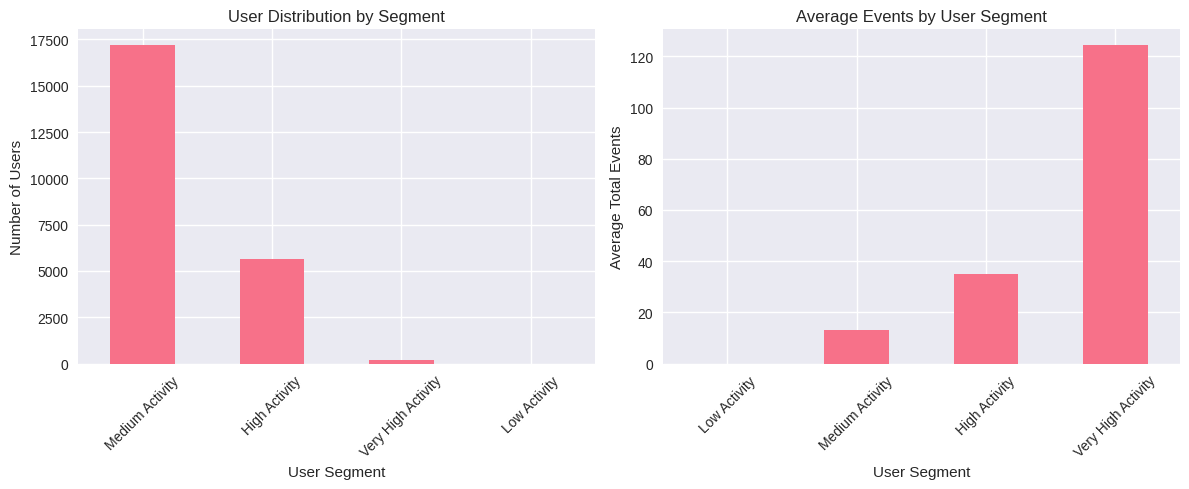


2. Product Performance Analysis:
Product Segment Analysis:
                      total_views  unique_users  avg_views_per_user
product_segment                                                    
Low Popularity               2.84          1.98                1.47
Medium Popularity           24.11         10.88                3.34
High Popularity            164.16         59.34                5.34
Very High Popularity          NaN           NaN                 NaN

3. Recommendation Strategy Insights:
Based on the analysis, here are the key insights and recommendations:

A. User Behavior Insights:
- Most users have low to medium activity levels
- User engagement varies significantly across time periods
- There's a long-tail distribution in product popularity

B. Recommendation Strategies:
1. For New Users:
   - Use content-based filtering with popular items
   - Recommend items from high-popularity segments
2. For Active Users:
   - Use collaborative filtering for personalized recommend

In [21]:
print("=== BUSINESS INSIGHTS AND RECOMMENDATIONS ===")

# 1. User Segmentation
print("\n1. User Segmentation Analysis:")

# Segment users based on activity
user_features['user_segment'] = pd.cut(
    user_features['total_events'],
    bins=[0, 5, 20, 100, float('inf')],
    labels=['Low Activity', 'Medium Activity', 'High Activity', 'Very High Activity']
)

segment_analysis = user_features.groupby('user_segment').agg({
    'total_events': 'mean',
    'unique_items': 'mean',
    'activity_duration': 'mean'
}).round(2)

print("User Segment Analysis:")
print(segment_analysis)

# Visualize user segments
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
user_features['user_segment'].value_counts().plot(kind='bar')
plt.title('User Distribution by Segment')
plt.xlabel('User Segment')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
segment_analysis['total_events'].plot(kind='bar')
plt.title('Average Events by User Segment')
plt.xlabel('User Segment')
plt.ylabel('Average Total Events')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 2. Product Performance Analysis
print("\n2. Product Performance Analysis:")

# Segment products based on popularity
item_features['product_segment'] = pd.cut(
    item_features['total_views'],
    bins=[0, 10, 100, 1000, float('inf')],
    labels=['Low Popularity', 'Medium Popularity', 'High Popularity', 'Very High Popularity']
)

product_segment_analysis = item_features.groupby('product_segment').agg({
    'total_views': 'mean',
    'unique_users': 'mean',
    'avg_views_per_user': 'mean'
}).round(2)

print("Product Segment Analysis:")
print(product_segment_analysis)

# 3. Recommendation Strategy
print("\n3. Recommendation Strategy Insights:")

print("Based on the analysis, here are the key insights and recommendations:")

print("\nA. User Behavior Insights:")
print("- Most users have low to medium activity levels")
print("- User engagement varies significantly across time periods")
print("- There's a long-tail distribution in product popularity")

print("\nB. Recommendation Strategies:")
print("1. For New Users:")
print("   - Use content-based filtering with popular items")
print("   - Recommend items from high-popularity segments")

print("2. For Active Users:")
print("   - Use collaborative filtering for personalized recommendations")
print("   - Leverage user similarity for cross-selling")

print("3. For High-Value Users:")
print("   - Implement hybrid approaches combining multiple algorithms")
print("   - Focus on niche and trending products")

print("\nC. Implementation Recommendations:")
print("1. Start with content-based filtering for cold-start problem")
print("2. Gradually introduce collaborative filtering as user data accumulates")
print("3. Use matrix factorization for handling sparsity")
print("4. Implement real-time recommendation updates")
print("5. A/B test different recommendation strategies")